# CAVAS — Deep Learning Model Evaluation
### IDS Intrusion Detection: TabNet (Tabular) + TFT (Time Series)

**Dual prediction targets:**
- `label_generic` → Binary classification (benign / malicious)
- `Label` → Multiclass classification (benign / attack type)

**Models:**
- **TabNet** — sequential attention, native feature importance
- **Temporal Fusion Transformer (TFT)** — variable selection networks + temporal attention

**Hyperparameter tuning:** Optuna (TPE sampler)

---

### Notebook Workflow (5 steps)
1. **HPO (0.1% dataset):** Optuna hyperparameter search for TabNet & TFT — save all trial models + confusion matrices
2. **Best models & Feature Importance:** Extract best trial per model, plot feature importance
3. **Top features intersection:** Top-10 features from each model → intersection (~8–10 features)
4. **10% dataset (reduced features):** Stratified 10% sample, keep only important features
5. **Baseline training:** Retrain both models on the 10% reduced-feature dataset with optimized hyperparams

In [1]:
LOCAL_RUN = True
RANDOM_SEED = 42
RUNNINNG_ON_LINIX = True
TRIALS_ALREADY_EXECUTED = True
MIN_SAMPLES_PER_CLASS = 5

PERCENTAGE_TO_USE = 0.1  # 0.1% del dataset (stratificato per label_generic)
WINDOW_SIZE = 50   # finestra temporale per CNN-LSTM
STEP_SIZE   = 10   # overlap tra finestre

## 0. Configuration & Setup

In [2]:
!pip install -q pytorch-tabnet pytorch-forecasting pytorch-lightning optuna optuna-integration scikit-learn pandas pyarrow


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import os, subprocess, warnings, json
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import math

# Spark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col
from pyspark.ml.feature import StringIndexer

# Sklearn
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.metrics          import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, matthews_corrcoef
)

# TabNet — multi-task classifier (predicts both targets simultaneously)
from pytorch_tabnet.multitask import TabNetMultiTaskClassifier

# TFT — use lightning.pytorch (NOT pytorch_lightning) to match pytorch_forecasting
import torch
import lightning.pytorch as pl

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Optuna
import optuna
from optuna.integration import PyTorchLightningPruningCallback
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
pl.seed_everything(RANDOM_SEED)
print("All imports OK")

/home/cava/Documents/Repos/python/pucktrick/.venv/lib/python3.10/site-packages/pytorch_forecasting/models/base/_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
Seed set to 42


All imports OK


In [29]:
# ─────────────────────────────────────────────────────────────────────
# CONFIGURATION — change only here
# ─────────────────────────────────────────────────────────────────────
PATH_IMG = "images"

if LOCAL_RUN:
    PATH = "DATASETS"
    TABNET_MAX_EPOCHS  = 20
    CNN_LSTM_MAX_EPOCHS= 50
else:
    PATH = "file:///home/PuckTrickadmin/DATASETS"
    TABNET_MAX_EPOCHS  = 150
    CNN_LSTM_MAX_EPOCHS= 100

RANDOM_SEED  = 42
# Split temporale: non servono più TEST_SIZE / VAL_SIZE
# La suddivisione è deterministica: ogni 3 pacchetti → 2 train, 1 temp
# Da temp → alternato val / test (≈66.7% train, 16.7% val, 16.7% test)

os.makedirs(PATH_IMG, exist_ok=True)
os.makedirs("models",  exist_ok=True)

In [5]:
# ── Spark session (LOCAL / SERVER) ──────────────────────────────────
if LOCAL_RUN:
    if (RUNNINNG_ON_LINIX):
        java_home = os.environ.get('JAVA_HOME', '')
        if not java_home:
            try:
                java_path = subprocess.check_output(['which', 'java'], text=True).strip()
                os.environ['JAVA_HOME'] = os.path.dirname(os.path.dirname(os.path.realpath(java_path)))
            except subprocess.CalledProcessError:
                print("⚠️  Java not found — run: sudo apt install default-jdk")

        os.environ['PYSPARK_PYTHON']        = 'python3'
        os.environ['PYSPARK_DRIVER_PYTHON'] = 'python3'

        spark = SparkSession.builder \
            .appName("CAVAS_Models") \
            .master("local[*]") \
            .config("spark.driver.memory",          "24g") \
            .config("spark.driver.host",            "localhost") \
            .config("spark.ui.showConsoleProgress", "false") \
            .getOrCreate()
        
    else:
        # Forza JAVA_HOME al JRE corretto
        os.environ['JAVA_HOME'] = r"C:\Program Files\Java\jre-1.8"

        # Hadoop winutils per Windows
        os.environ['HADOOP_HOME'] = r"C:\hadoop"
        os.environ['PATH'] = os.environ.get('PATH', '') + r';C:\hadoop\bin'

        # Su Windows l'eseguibile è 'python', non 'python3'
        py = 'python' if os.name == 'nt' else 'python3'
        os.environ['PYSPARK_PYTHON']        = py
        os.environ['PYSPARK_DRIVER_PYTHON'] = py

        spark = SparkSession.builder \
            .appName("CAVAS_Models") \
            .master("local[*]") \
            .config("spark.driver.memory",          "24g") \
            .config("spark.driver.host",            "localhost") \
            .config("spark.ui.showConsoleProgress", "false") \
            .getOrCreate()
        
else:
    MASTER_URL  = "spark://10.0.1.8:7077"
    DRIVER_HOST = "10.0.1.8"

    spark = SparkSession.builder \
        .appName("CAVAS_Models") \
        .master(MASTER_URL) \
        .config("spark.submit.deployMode",      "client") \
        .config("spark.executor.instances",     "4") \
        .config("spark.executor.cores",         "4") \
        .config("spark.executor.memory",        "13g") \
        .config("spark.driver.memory",          "8g") \
        .config("spark.driver.host",            DRIVER_HOST) \
        .config("spark.driver.bindAddress",     DRIVER_HOST) \
        .config("spark.sql.shuffle.partitions", "32") \
        .getOrCreate()
    spark.sparkContext.setLogLevel("WARN")

print(f"✅  Spark {spark.version} ready")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/07 03:11:46 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅  Spark 3.5.0 ready


## 0.1. Data Loading — Stratified Sample + Timestamp Cleanup

In [6]:
# Feature types from your analysis
CATEGORICAL_FEATURES = ['Fwd Seg Size Min', 'Protocol']
BINARY_FEATURES      = ['FIN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'Fwd URG Flag', 'Fwd PSH Flag']

In [7]:
def label_encoding_spark(sdf):
    """Add label_generic_enc (0/1) and Label_enc (integer) to the Spark DataFrame.
    Returns (sdf_encoded, label_classes) where label_classes maps index → Label name.
    """
    # ── Binary: label_generic is already 0/1 → cast to int ──────────
    sdf = sdf.withColumn('label_generic_enc', col('label_generic').cast('int'))

    # ── Multiclass: Label → integer index via StringIndexer ──────────
    indexer = StringIndexer(inputCol='Label', outputCol='Label_enc', handleInvalid='keep')
    model = indexer.fit(sdf)
    sdf = model.transform(sdf)
    sdf = sdf.withColumn('Label_enc', col('Label_enc').cast('int'))

    # Store ordered label list: index 0 → labels[0], etc.
    label_classes = list(model.labels)

    n_binary = sdf.select('label_generic_enc').distinct().count()
    print(f"✅  label_generic_enc: {n_binary} classes | Label_enc: {len(label_classes)} classes")
    print(f"    Label mapping: { {i: l for i, l in enumerate(label_classes)} }")
    return sdf, label_classes

In [8]:
def preprocess_to_pandas(sdf, continuous_features, categorical_features, binary_features):
    """
    Convert Spark → Pandas and clean dtypes.
    
    - Continuous: cast to float64 (scaling done AFTER train/test split to avoid leakage)
    - Categorical: integer-encoded via LabelEncoder (TabNet/TFT handle them natively)
    - Binary: cast to int
    
    ⚠ NO one-hot encoding:
      • TabNet uses cat_idxs / cat_dims natively
      • TFT uses time_varying_known_categoricals
      • Feature importance stays traceable to the original feature name
    """
    print("⏳  Converting Spark → Pandas ...")
    pdf = sdf.toPandas()
    print(f"📊  Shape: {pdf.shape}")

    available = set(pdf.columns)
    cont_cols = [c for c in continuous_features if c in available]
    cat_cols  = [c for c in categorical_features if c in available]
    bin_cols  = [c for c in binary_features if c in available]

    # ── Continuous → float64 ──────────────────────────────────────────
    for c in cont_cols:
        pdf[c] = pd.to_numeric(pdf[c], errors='coerce')
    pdf[cont_cols] = pdf[cont_cols].fillna(0.0)

    # ── Categorical → integer codes ──────────────────────────────────
    cat_encoders = {}
    cat_dims = {}
    for c in cat_cols:
        le = LabelEncoder()
        pdf[c] = le.fit_transform(pdf[c].astype(str))
        cat_encoders[c] = le
        cat_dims[c] = len(le.classes_)

    # ── Binary → int ─────────────────────────────────────────────────
    for c in bin_cols:
        pdf[c] = pd.to_numeric(pdf[c], errors='coerce').fillna(0).astype(int)

    print(f"✅  Preprocessed: {len(cont_cols)} continuous | {len(cat_cols)} categorical | {len(bin_cols)} binary")
    return pdf, cat_encoders, cat_dims

## Step 1: Models functions

Both models are tuned via Optuna on a 0.1% stratified sample.  
Each trial's model is stored in memory along with confusion matrices for both targets.

### Step 1.0. Utility functions

In [9]:
# ── Utility function for metrics ─────────────────────────────────────
def print_metrics(y_true, y_pred, y_proba, task_name, class_names=None, verbose=1):
    is_binary = (len(np.unique(y_true)) == 2)
    acc = accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='binary' if is_binary else 'macro')
    try:
        auc = roc_auc_score(
            y_true,
            y_proba[:, 1] if is_binary else y_proba,
            multi_class='ovr' if not is_binary else 'raise'
        )
    except Exception:
        auc = float('nan')

    if verbose != 0:
        print(f"\n{'='*55}")
        print(f"  {task_name}")
        print(f"{'='*55}")
        print(f"  Accuracy : {acc:.4f}  |  F1: {f1:.4f}  |  MCC: {mcc:.4f}  |  AUC: {auc:.4f}")
    present_labels = sorted(np.unique(np.concatenate([np.unique(y_true), np.unique(y_pred)])))
    if class_names is not None:
        target_names_filtered = [class_names[i] for i in present_labels if i < len(class_names)]
    else:
        target_names_filtered = None
    if verbose != 0:
        print(classification_report(y_true, y_pred, labels=present_labels,
                                    target_names=target_names_filtered))
    return dict(task=task_name, accuracy=acc, f1=f1, mcc=mcc, auc=auc)

In [10]:
# ── Utility: show stored model report ─────────────────────────────────
def show_model_report(model_name, artifacts_dict=None):
    """
    Display confusion matrices + key metrics for a previously-run trial.
    
    Parameters
    ----------
    model_name : str or int
        The key used in tabnet_trial_artifacts / tft_trial_artifacts,
        e.g. trial number (int) or 'Baseline' / 'TFT_Baseline' (str).
    artifacts_dict : dict, optional
        If provided, look up model_name in this dict directly.
        Otherwise tries tabnet_trial_artifacts first, then tft_trial_artifacts.
    """
    # ── Locate the artifact ───────────────────────────────────────────
    art = None
    if artifacts_dict is not None:
        art = artifacts_dict.get(model_name)
    else:
        art = tabnet_trial_artifacts.get(model_name) or cnn_lstm_trial_artifacts.get(model_name)

    if art is None:
        # Try loading from JSON on disk
        for prefix in ['tabnet_trial_', 'cnn_lstm_trial_']:
            path = f'models/{prefix}{model_name}_artifacts.json'
            if os.path.exists(path):
                with open(path) as f:
                    art = json.load(f)
                break
    if art is None:
        print(f"❌  No artifacts found for '{model_name}'")
        return

    model_type = art.get('model_type', 'Unknown')
    label      = art.get('label', str(model_name))

    print(f"\n{'='*60}")
    print(f"  📊  Report: {model_type} — {label}")
    print(f"{'='*60}")

    # ── Scalar metrics ────────────────────────────────────────────────
    for task_key, task_label in [('metrics_binary', 'Binary Task'),
                                  ('metrics_multiclass', 'Multiclass Task')]:
        m = art.get(task_key)
        if m is None:
            print(f"\n  ⚠️  {task_label}: metrics not available")
            continue
        print(f"\n  {task_label}:")
        print(f"    Accuracy : {m['accuracy']:.4f}")
        print(f"    F1-score : {m['f1']:.4f}")
        print(f"    MCC      : {m['mcc']:.4f}")
        print(f"    AUC      : {m['auc']:.4f}")

    # ── Extra scalars (model-specific) ────────────────────────────────
    if 'mean_mcc' in art:
        print(f"\n  Mean MCC (binary+multi): {art['mean_mcc']:.4f}")
    if 'val_loss' in art:
        print(f"  Val loss: {art['val_loss']:.4f}")

    # ── Confusion matrices ────────────────────────────────────────────
    cm_bin = art.get('cm_bin')
    cm_mul = art.get('cm_mul')

    if cm_bin is None and cm_mul is None:
        print("\n  ⚠️  No confusion matrices available for this trial")
        return

    # Convert from list-of-lists (JSON) back to ndarray if needed
    if cm_bin is not None and not isinstance(cm_bin, np.ndarray):
        cm_bin = np.array(cm_bin)
    if cm_mul is not None and not isinstance(cm_mul, np.ndarray):
        cm_mul = np.array(cm_mul)

    n_plots = (cm_bin is not None) + (cm_mul is not None)
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]

    idx = 0
    if cm_bin is not None:
        sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
        axes[idx].set_title(f'{label} — Binary CM')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')
        idx += 1

    if cm_mul is not None:
        sns.heatmap(cm_mul, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
        axes[idx].set_title(f'{label} — Multiclass CM')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()
    print(f"\n  Params: {json.dumps(art.get('params', {}), indent=4)}")
    
    # ── Feature importance ────────────────────────────────────────────
    fi = art.get('feature_importance')
    if fi:
        fi_sorted = dict(sorted(fi.items(), key=lambda x: x[1], reverse=True))
        top_n = dict(list(fi_sorted.items())[:20])  # top 20

        print(f"\n  Top feature importances (top {len(top_n)}):")
        fig_fi, ax_fi = plt.subplots(figsize=(8, max(3, len(top_n) * 0.35)))
        ax_fi.barh(list(top_n.keys())[::-1], list(top_n.values())[::-1], color='steelblue')
        ax_fi.set_xlabel('Importance')
        ax_fi.set_title(f'{label} — Feature Importance')
        plt.tight_layout()
        plt.show()
    else:
        print("\n  ⚠️  Feature importance not available for this trial")

In [11]:
def json_serializer(x):
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, (np.floating, np.integer)):
        return None if np.isnan(x) else x.item()
    if isinstance(x, float) and np.isnan(x):
        return None  # NaN → null in JSON
    return str(x)

### Step 1a — TabNet Hyperparameter Tuning (Optuna)

**Key TabNet hyperparameters:**
| Param | Meaning |
|---|---|
| `N_a` / `N_d` | Width of attention + decision steps (usually equal) |
| `N_steps` | Number of sequential attention steps |
| `gamma` | Sparsity regularisation coefficient |
| `lambda_sparse` | Feature sparsity penalty |
| `lr` | Learning rate |

Each trial's model, confusion matrices (binary + multiclass), and metrics are saved in memory.

In [12]:
tabnet_trial_artifacts = {}

In [13]:
# ── Global storage for TabNet trial artifacts ─────────────────────────
def tabnet_multitask_objective(X_train, X_val,
                                y_tr_bin, y_tr_mul,
                                y_val_bin, y_val_mul,
                                N_a, N_steps, gamma, lambda_s, lr, batch_sz, mask_type,
                                verbose=0, trial=None, label_model=None,
                                feature_names=None):
    """
    Stores model + confusion matrices in memory for each trial.
    Returns mean MCC across both tasks on validation set.
    """
    ## Usa solo una delle due etichette per identificare il trial (label_model se fornita, altrimenti trial.number)
    FINAL_LABEL = label_model if label_model is not None else trial.number
    
    clf = TabNetMultiTaskClassifier(
        n_d=N_a, n_a=N_a,
        n_steps=N_steps,
        gamma=gamma,
        lambda_sparse=lambda_s,
        cat_idxs=CAT_IDXS if CAT_IDXS else [],
        cat_dims=CAT_DIMS if CAT_DIMS else [],
        cat_emb_dim=1,
        optimizer_params=dict(lr=lr),
        mask_type=mask_type,
        verbose=verbose,
        seed=RANDOM_SEED,
    )

    y_train_mt = np.column_stack([y_tr_bin, y_tr_mul])
    y_val_mt   = np.column_stack([y_val_bin, y_val_mul])

    clf.fit(
        X_train,
        y_train_mt,
        eval_set      = [(X_val, y_val_mt)],
        eval_metric   = ['accuracy'],
        max_epochs    = TABNET_MAX_EPOCHS,
        patience      = 4,
        batch_size    = batch_sz,
        virtual_batch_size = max(batch_sz // 4, 64),
        drop_last     = False,
    )

    # predict() returns a list: [preds_task0, preds_task1]
    # ⚠️ Cast esplicito a int — TabNet può restituire dtype=object/float
    raw_preds = clf.predict(X_val)
    pred_bin = np.asarray(raw_preds[0]).astype(int)
    pred_mul = np.asarray(raw_preds[1]).astype(int)
    y_val_bin_int = np.asarray(y_val_bin).astype(int)
    y_val_mul_int = np.asarray(y_val_mul).astype(int)

    mcc_bin = matthews_corrcoef(y_val_bin_int, pred_bin)
    mcc_mul = matthews_corrcoef(y_val_mul_int, pred_mul)

    # ── Confusion matrices for both labels ────────────────────────────
    cm_bin = confusion_matrix(y_val_bin_int, pred_bin)
    cm_mul = confusion_matrix(y_val_mul_int, pred_mul)

    # Save confusion matrices to CSV
    #pd.DataFrame(cm_bin).to_csv(f'models/tabnet_trial{FINAL_LABEL}_cm_binary.csv', index=False)
    #pd.DataFrame(cm_mul).to_csv(f'models/tabnet_trial{FINAL_LABEL}_cm_multiclass.csv', index=False)
    
    # Plot confusion matrix
    if verbose != 0:
        print(f"\nConfusion Matrix - Trial {FINAL_LABEL}:")
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                    xticklabels=['Benign', 'Malicious'],
                    yticklabels=['Benign', 'Malicious'])
        axes[0].set_title(f'Trial {FINAL_LABEL} — Binary CM')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')

        sns.heatmap(cm_mul, annot=True, fmt='d', cmap='Blues', ax=axes[1],
                    xticklabels=label_classes[:cm_mul.shape[1]],
                    yticklabels=label_classes[:cm_mul.shape[0]])
        axes[1].set_title(f'Trial {FINAL_LABEL} — Multiclass CM')
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('Actual')
        plt.xticks(rotation=45, ha='right')

        plt.tight_layout()
        plt.savefig(f'{PATH_IMG}/tabnet_trial{FINAL_LABEL}_cm.png', dpi=150, bbox_inches='tight')
        plt.show()
        
    proba = clf.predict_proba(X_val)
    metrics_first_output = print_metrics(y_val_bin_int, pred_bin, proba[0],
                      f'Trial {FINAL_LABEL} - Binary Task',
                      class_names=['Benign', 'Malicious'], verbose=verbose)
    metrics_second_output = print_metrics(y_val_mul_int, pred_mul, proba[1],
                      f'Trial {FINAL_LABEL} - Multiclass Task',
                      class_names=label_classes, verbose=verbose)
    
    # In tabnet_multitask_objective, dopo clf.fit():
    if feature_names is not None:
        feat_names = list(feature_names)
    elif hasattr(X_train, 'columns'):  # DataFrame passato per sbaglio
        feat_names = list(X_train.columns)
    else:
        feat_names = [f'f{i}' for i in range(X_train.shape[1])]
    importance_scores = clf.feature_importances_  # np.array shape (n_features,)
    feature_importance = dict(zip(feature_names, importance_scores.tolist()))

    # ── Store model and artifacts in memory ───────────────────────────
    mean_mcc = (mcc_bin + mcc_mul) / 2
    object_to_store = {
        'model': f'tabnet_trial_{FINAL_LABEL}',
        'model_type': 'TabNet',
        'label': str(FINAL_LABEL),
        'mcc_bin': mcc_bin,
        'mcc_mul': mcc_mul,
        'mean_mcc': mean_mcc,
        'cm_bin': cm_bin,
        'cm_mul': cm_mul,
        'feature_importance': feature_importance,  # {feature_name: score}
        'params': trial.params if trial is not None else {
            'N_a': N_a, 'N_steps': N_steps, 'gamma': gamma,
            'lambda_sparse': lambda_s, 'lr': lr, 'batch_size': batch_sz, 'mask_type': mask_type
        },
        'metrics_binary': metrics_first_output,
        'metrics_multiclass': metrics_second_output,
    }
    tabnet_trial_artifacts[FINAL_LABEL] = object_to_store
    tabnet_trial_artifacts[FINAL_LABEL]['_live_model'] = clf 
    
    model_path = f'models/tabnet_trial_{FINAL_LABEL}'
    clf.save_model(model_path)
    
    # Save object to json for later analysis
    with open(f'models/tabnet_trial_{FINAL_LABEL}_artifacts.json', 'w') as f:
        json.dump(object_to_store, f, indent=4, default=json_serializer)

    print(f"  Trial {FINAL_LABEL}: MCC_bin={mcc_bin:.4f}, MCC_mul={mcc_mul:.4f}, mean={mean_mcc:.4f}")
    return mean_mcc

### Step 1b — CNN-LSTM (Time Series)

**Strategy: Single Continuous Time Series**

The entire dataset represents a **single continuous network capture session** ordered by `Timestamp`.
Flows are sorted chronologically and indexed sequentially to form a unified time series.
This allows TFT to learn temporal patterns in attack campaigns (port scans, DDoS bursts, etc.)
by looking at the sequence of flows over time.

Each trial's model, confusion matrices (when computable), and metrics are saved in memory.

In [14]:
# ── Global storage for TFT trial artifacts ────────────────────────────
cnn_lstm_trial_artifacts = {}

In [15]:
class CNNLSTMMultiTask(nn.Module):
    def __init__(self, n_features, n_timesteps, n_classes_bin, n_classes_mul,
                 nb_filters=64, kernel_size=3, lstm_units_1=64,
                 lstm_units_2=128, dropout=0.3):
        super().__init__()

        # CNN opera su (batch, n_features, n_timesteps)
        # ogni feature è un canale, i timesteps sono la dimensione spaziale
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=n_features, out_channels=nb_filters,
                      kernel_size=kernel_size, padding=kernel_size // 2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.BatchNorm1d(nb_filters),
        )

        self.lstm1 = nn.LSTM(input_size=nb_filters, hidden_size=lstm_units_1,
                             batch_first=True)
        self.lstm2 = nn.LSTM(input_size=lstm_units_1, hidden_size=lstm_units_2,
                             batch_first=True)
        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Sequential(
            nn.Linear(lstm_units_2, lstm_units_2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.head_bin = nn.Linear(lstm_units_2, n_classes_bin)
        self.head_mul = nn.Linear(lstm_units_2, n_classes_mul)

    def forward(self, x):
        # x: (batch, n_timesteps, n_features)
        x = x.permute(0, 2, 1)        # → (batch, n_features, n_timesteps)
        x = self.cnn(x)                # → (batch, nb_filters, timesteps//2)
        x = x.permute(0, 2, 1)        # → (batch, timesteps//2, nb_filters)
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = x[:, -1, :]               # ultimo timestep
        x = self.dropout(x)
        x = self.fc(x)
        return self.head_bin(x), self.head_mul(x)

In [38]:
def cnn_lstm_multitask_objective(X_train, X_val,
                                  y_tr_bin, y_tr_mul,
                                  y_val_bin, y_val_mul,
                                  nb_filters, kernel_size,
                                  lstm_units_1, lstm_units_2,
                                  dropout, lr, batch_size,
                                  verbose=0, trial=None, label_model=None,
                                  feature_names=None):
    """
    X_train / X_val: 3D arrays (n_samples, n_timesteps, n_features)
    """
    FINAL_LABEL = label_model if label_model is not None else trial.number
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # ── Dataloader (3D tensors) ───────────────────────────────────────
    def make_loader(X, yb, ym, shuffle):
        ds = TensorDataset(
            torch.tensor(X, dtype=torch.float32),   # (N, T, F)
            torch.tensor(yb, dtype=torch.long),
            torch.tensor(ym, dtype=torch.long),
        )
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

    train_dl = make_loader(X_train, y_tr_bin, y_tr_mul, shuffle=False)
    val_dl   = make_loader(X_val,   y_val_bin, y_val_mul, shuffle=False)

    # ── Modello (3D: batch, n_timesteps, n_features) ──────────────────
    n_features  = X_train.shape[2]
    n_timesteps = X_train.shape[1]

    model = CNNLSTMMultiTask(
        n_features    = n_features,
        n_timesteps   = n_timesteps,
        n_classes_bin = len(np.unique(y_tr_bin)),
        n_classes_mul = len(np.unique(y_tr_mul)),
        nb_filters    = nb_filters,
        kernel_size   = kernel_size,
        lstm_units_1  = lstm_units_1,
        lstm_units_2  = lstm_units_2,
        dropout       = dropout,
    ).to(device)

    optimizer  = optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=3,       # aspetta 3 epoche senza miglioramento
        min_lr=1e-8
    )
    loss_bin   = nn.CrossEntropyLoss()
    loss_mul   = nn.CrossEntropyLoss()

    # ── Training ──────────────────────────────────────────────────────
    best_val_loss = float('inf')
    patience_counter = 0
    PATIENCE = 10
    val_losses = []

    for epoch in range(CNN_LSTM_MAX_EPOCHS):
        model.train()
        for X_b, yb_b, ym_b in train_dl:
            X_b, yb_b, ym_b = X_b.to(device), yb_b.to(device), ym_b.to(device)
            optimizer.zero_grad()
            out_bin, out_mul = model(X_b)
            loss = loss_bin(out_bin, yb_b) + loss_mul(out_mul, ym_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # ← gradient clipping reale
            optimizer.step()

        # Validation
        model.eval()
        val_loss_epoch = 0.0
        with torch.no_grad():
            for X_b, yb_b, ym_b in val_dl:
                X_b, yb_b, ym_b = X_b.to(device), yb_b.to(device), ym_b.to(device)
                out_bin, out_mul = model(X_b)
                val_loss_epoch += (loss_bin(out_bin, yb_b) + loss_mul(out_mul, ym_b)).item()

        val_loss_epoch /= len(val_dl)
        val_losses.append(val_loss_epoch)

        scheduler.step(val_loss_epoch)  # ← aggiorna LR in base alla val_loss

        if verbose != 0:
            print(f"  Epoch {epoch+1:3d} | val_loss: {val_loss_epoch:.4f}")

        # Early stopping
        if val_loss_epoch < best_val_loss:
            best_val_loss = val_loss_epoch
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                if verbose != 0:
                    print(f"  Early stopping at epoch {epoch+1}")
                break

        # Optuna pruning
        if trial is not None:
            trial.report(val_loss_epoch, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    # Ripristina best weights
    model.load_state_dict(best_state)

    # ── Evaluation ────────────────────────────────────────────────────
    model.eval()
    all_pred_bin, all_pred_mul = [], []
    all_prob_bin, all_prob_mul = [], []
    all_true_bin, all_true_mul = [], []

    with torch.no_grad():
        for X_b, yb_b, ym_b in val_dl:
            X_b = X_b.to(device)
            out_bin, out_mul = model(X_b)
            prob_bin = torch.softmax(out_bin, dim=1).cpu().numpy()
            prob_mul = torch.softmax(out_mul, dim=1).cpu().numpy()
            all_pred_bin.extend(prob_bin.argmax(axis=1))
            all_pred_mul.extend(prob_mul.argmax(axis=1))
            all_prob_bin.append(prob_bin)
            all_prob_mul.append(prob_mul)
            all_true_bin.extend(yb_b.numpy())
            all_true_mul.extend(ym_b.numpy())

    pred_bin = np.array(all_pred_bin)
    pred_mul = np.array(all_pred_mul)
    prob_bin = np.vstack(all_prob_bin)
    prob_mul = np.vstack(all_prob_mul)
    true_bin = np.array(all_true_bin)
    true_mul = np.array(all_true_mul)

    mcc_bin = matthews_corrcoef(true_bin, pred_bin)
    mcc_mul = matthews_corrcoef(true_mul, pred_mul)
    mean_mcc = (mcc_bin + mcc_mul) / 2

    cm_bin = confusion_matrix(true_bin, pred_bin)
    cm_mul = confusion_matrix(true_mul, pred_mul)

    metrics_first_output  = print_metrics(true_bin, pred_bin, prob_bin,
                                           f'Trial {FINAL_LABEL} - Binary Task',
                                           class_names=['Benign', 'Malicious'],
                                           verbose=verbose)
    metrics_second_output = print_metrics(true_mul, pred_mul, prob_mul,
                                           f'Trial {FINAL_LABEL} - Multiclass Task',
                                           class_names=label_classes, verbose=verbose)

    # ── Feature importance (permutation-based, 3D) ────────────────────
    feature_importance = None
    try:
        feat_names = list(feature_names) if feature_names is not None \
                     else [f'f{i}' for i in range(n_features)]

        base_acc = (pred_bin == true_bin).mean()
        importances = {}
        X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)

        for i in range(n_features):                     # axis 2 = features
            X_perm = X_val_t.clone()
            idx = torch.randperm(X_val_t.shape[0])
            X_perm[:, :, i] = X_val_t[idx, :, i]        # permuta su tutti i timestep
            with torch.no_grad():
                out_b, _ = model(X_perm)
                p = out_b.argmax(dim=1).cpu().numpy()
            drop = base_acc - (p == true_bin).mean()
            importances[feat_names[i]] = float(drop)

        # Normalizza a [0,1]
        max_imp = max(importances.values()) or 1.0
        feature_importance = {k: max(v, 0) / max_imp
                               for k, v in importances.items()}
    except Exception as e:
        print(f"  ⚠️ Feature importance failed (trial {FINAL_LABEL}): {e}")

    # ── Plot confusion matrix ─────────────────────────────────────────
    if verbose != 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                    xticklabels=['Benign', 'Malicious'],
                    yticklabels=['Benign', 'Malicious'])
        axes[0].set_title(f'Trial {FINAL_LABEL} — Binary CM')
        axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
        sns.heatmap(cm_mul, annot=True, fmt='d', cmap='Blues', ax=axes[1],
                    xticklabels=label_classes[:cm_mul.shape[1]],
                    yticklabels=label_classes[:cm_mul.shape[0]])
        axes[1].set_title(f'Trial {FINAL_LABEL} — Multiclass CM')
        axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(f'{PATH_IMG}/cnn_lstm_trial{FINAL_LABEL}_cm.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

        # Loss curve
        best_epoch = int(np.argmin(val_losses))
        fig_l, ax_l = plt.subplots(figsize=(8, 4))
        ax_l.plot(val_losses, marker='o', markersize=3, linewidth=1.5, color='steelblue')
        ax_l.scatter([best_epoch], [val_losses[best_epoch]], color='red', zorder=5,
                     label=f'Best: epoch {best_epoch}, loss={val_losses[best_epoch]:.4f}')
        ax_l.set_xlabel('Epoch'); ax_l.set_ylabel('Val Loss')
        ax_l.set_title(f'Trial {FINAL_LABEL} — Validation Loss Curve')
        ax_l.legend(); ax_l.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{PATH_IMG}/cnn_lstm_trial{FINAL_LABEL}_loss.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

    # ── Salva modello e artifacts ─────────────────────────────────────
    model_path = f'models/cnn_lstm_trial_{FINAL_LABEL}.pt'
    torch.save(model.state_dict(), model_path)

    object_to_store = {
        'model':              model_path,
        'model_type':         'CNN-LSTM',
        'label':              str(FINAL_LABEL),
        'mcc_bin':            mcc_bin,
        'mcc_mul':            mcc_mul,
        'mean_mcc':           mean_mcc,
        'val_loss':           best_val_loss,
        'cm_bin':             cm_bin.tolist(),
        'cm_mul':             cm_mul.tolist(),
        'feature_importance': feature_importance,
        'params': trial.params if trial is not None else {
            'nb_filters': nb_filters, 'kernel_size': kernel_size,
            'lstm_units_1': lstm_units_1, 'lstm_units_2': lstm_units_2,
            'dropout': dropout, 'lr': lr, 'batch_size': batch_size,
        },
        'metrics_binary':     metrics_first_output,
        'metrics_multiclass': metrics_second_output,
    }
    cnn_lstm_trial_artifacts[FINAL_LABEL] = {**object_to_store, '_live_model': model}

    f1_bin = metrics_first_output['f1']
    f1_mul = metrics_second_output['f1']
    f1_mean = (f1_bin + f1_mul) / 2

    with open(f'models/cnn_lstm_trial_{FINAL_LABEL}_artifacts.json', 'w') as f:
        json.dump(object_to_store, f, indent=4, default=json_serializer)

    print(f"  Trial {FINAL_LABEL}: MCC_bin={mcc_bin:.4f}, MCC_mul={mcc_mul:.4f}, mean={mean_mcc:.4f}, F1_bin={f1_bin:.4f}, F1_mul={f1_mul:.4f}")
    return f1_mean

## Step 3: Top Feature Intersection

Take the **top 10 features** from each model (TabNet + TFT) and compute their **intersection**.  
This gives the ~8–10 features that *both* models consider most important.  
If the intersection is too small (< 5), we fall back to a combined ranking.

### Helper functions

In [17]:
def reload_all_trial_metadata(models_dir='models'):
    """
    Ripopola tabnet_trial_artifacts e cnn_lstm_trial_artifacts
    con soli metadati (no model weights in memoria).
    """
    import re

    for fname in sorted(os.listdir(models_dir)):
        if not fname.endswith('_artifacts.json'):
            continue

        match = re.match(r'(tabnet|cnn_lstm)_trial_(.+)_artifacts\.json', fname)
        if not match:
            continue

        model_type = match.group(1)
        label_str  = match.group(2)
        try:
            label = int(label_str)
        except ValueError:
            label = label_str

        with open(os.path.join(models_dir, fname)) as f:
            art = json.load(f)

        # cm: list → np.ndarray
        if art.get('cm_bin') is not None:
            art['cm_bin'] = np.array(art['cm_bin'])
        if art.get('cm_mul') is not None:
            art['cm_mul'] = np.array(art['cm_mul'])

        art['_live_model'] = None  # esplicito: modello non caricato

        if model_type == 'tabnet':
            tabnet_trial_artifacts[label] = art
        elif model_type == 'cnn_lstm':
            cnn_lstm_trial_artifacts[label] = art

    print(f"✅  Metadata reload completo:")
    print(f"    tabnet_trial_artifacts   → {len(tabnet_trial_artifacts)} trials")
    print(f"    cnn_lstm_trial_artifacts → {len(cnn_lstm_trial_artifacts)} trials")

In [18]:
# Ricarica metadati di tutti i trials
reload_all_trial_metadata()

✅  Metadata reload completo:
    tabnet_trial_artifacts   → 11 trials
    cnn_lstm_trial_artifacts → 11 trials


### Best parameters Loading:

In [19]:
best_tabnet_trial_num = 0

fi_tabnet = [
    k for k, v in sorted(
        tabnet_trial_artifacts[best_tabnet_trial_num]['feature_importance'].items(),
        key=lambda item: item[1],
        reverse=True
    )
]

best_tabnet = tabnet_trial_artifacts[best_tabnet_trial_num]["params"]

In [20]:
best_cnn_lstm_trial_num = 1

fi_cnn_lstm = [
    k for k, v in sorted(
        cnn_lstm_trial_artifacts[best_cnn_lstm_trial_num]['feature_importance'].items(),
        key=lambda item: item[1],
        reverse=True
    )
]

best_cnn_lstm = cnn_lstm_trial_artifacts[best_cnn_lstm_trial_num]["params"]

## Step 5: Baseline Model Training

Retrain **new instances** of TabNet and TFT on the 10% reduced-feature dataset,  
using the **optimized hyperparameters from Step 1**.

These models are the **baseline** for subsequent noise-fragility experiments.

### 5.1. Temporal Packet-Based Split

**Strategia di split temporale (preserva ordine cronologico):**
1. Dati ordinati per `Timestamp`
2. Ogni 3 pacchetti consecutivi → **2 train**, **1 temp**
3. Da temp → alternato **val** / **test**

| Split | % approx | Descrizione |
|-------|----------|-------------|
| Train | ~66.7% | Pacchetti in posizione 0, 1 di ogni tripla |
| Val   | ~16.7% | Pacchetti temp pari |
| Test  | ~16.7% | Pacchetti temp dispari |

In [ ]:
def prepare_whole_dataset_from_scratch():
    global CAT_IDXS, CAT_DIMS, label_classes

    pct_label = f"{PERCENTAGE_TO_USE*100:.1f}pct".replace('.', '_')
    print(f"📦  Loading dataset and sampling {pct_label} stratified ...")

    # ── 1. Read important features from CSV ───────────────────────────
    imp_df = pd.read_csv('models/important_features.csv')
    important_features = imp_df['feature'].tolist()
    print(f"📋  Important features from CSV ({len(important_features)}): {important_features}")

    KEEP_ALWAYS = {'Label', 'label_generic', 'Timestamp'}

    # ── 2. Load parquet & keep only important columns ─────────────────
    sdf_full = spark.read.parquet(f'{PATH}/all_elaborated.parquet')
    all_cols = set(sdf_full.columns)
    cols_to_keep = [c for c in sdf_full.columns
                    if c in KEEP_ALWAYS or c in important_features]
    sdf_full = sdf_full.select(*cols_to_keep)
    print(f"✅  Kept {len(cols_to_keep)} columns (from {len(all_cols)})")

    # ── 3. Classify features (only among those actually kept) ─────────
    FEATURE_COLS = [c for c in important_features if c in set(cols_to_keep)]
    CAT_COLS  = [c for c in CATEGORICAL_FEATURES if c in FEATURE_COLS]
    BIN_COLS  = [c for c in BINARY_FEATURES      if c in FEATURE_COLS]
    CONT_COLS = [c for c in FEATURE_COLS if c not in CAT_COLS and c not in BIN_COLS]

    # ── 4. Cast types ─────────────────────────────────────────────────
    ts_dtype = dict(sdf_full.dtypes).get('Timestamp', 'string')
    if ts_dtype == 'string':
        sdf_full = sdf_full.withColumn(
            'Timestamp',
            F.to_timestamp(F.col('Timestamp'), 'dd/MM/yyyy HH:mm:ss')
        )
        print("📅  Timestamp string → TimestampType")

    dtypes_map = dict(sdf_full.dtypes)
    for c in FEATURE_COLS:
        if dtypes_map.get(c) not in ('double', 'float'):
            sdf_full = sdf_full.withColumn(c, F.col(c).cast('double'))
    print(f"✅  Cast {len(FEATURE_COLS)} feature columns → double")

    # ── 5. Remove corrupted 1970 rows ─────────────────────────────────
    n_before = sdf_full.count()
    sdf_full = sdf_full.filter(F.year(F.col('Timestamp')) > 1970)
    n_dropped = n_before - sdf_full.count()
    print(f"🗑️  Removed {n_dropped:,} rows with year 1970" if n_dropped
          else "✅  No 1970 rows found")

    # ── 6. Stratified sampling ────────────────────────────────────────
    if PERCENTAGE_TO_USE < 1.0:
        fractions = {
            row['label_generic']: PERCENTAGE_TO_USE
            for row in sdf_full.select('label_generic').distinct().collect()
        }
        sdf_sampled = sdf_full.sampleBy('label_generic', fractions=fractions,
                                        seed=RANDOM_SEED)
        print(f"📦  Stratified {PERCENTAGE_TO_USE*100:.1f}% → {sdf_sampled.count():,} rows")
    else:
        sdf_sampled = sdf_full
        print(f"📦  Full dataset → {sdf_sampled.count():,} rows")


    # ── 7. Sort by Timestamp + encode labels ──────────────────────────
    sdf_sampled = sdf_sampled.orderBy('Timestamp')
    sdf_sampled, label_classes = label_encoding_spark(sdf_sampled)

    # ── 8. Spark → Pandas ─────────────────────────────────────────────
    pdf, _, cat_dims_dict = preprocess_to_pandas(
        sdf_sampled, CONT_COLS, CAT_COLS, BIN_COLS
    )

    # ── 9. Set TabNet globals ─────────────────────────────────────────
    CAT_IDXS = [FEATURE_COLS.index(c) for c in CAT_COLS]
    CAT_DIMS = [cat_dims_dict[c] for c in CAT_COLS]
    print(f"\n🧮  Features: {len(FEATURE_COLS)} | Cat: {CAT_COLS} | Bin: {BIN_COLS}")

    # ── 10. Extract arrays & clean ────────────────────────────────────
    X_all    = pdf[FEATURE_COLS].values.astype(np.float32)
    X_all    = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)
    X_all    = np.clip(X_all, -np.finfo(np.float32).max, np.finfo(np.float32).max)
    ybin_all = pdf['label_generic_enc'].values.astype(int)
    ymul_all = pdf['Label_enc'].values.astype(int)
    print(f"📊  X shape: {X_all.shape}")

    # ── 11. Filter rare multiclass labels ─────────────────────────────
    classes, counts = np.unique(ymul_all, return_counts=True)
    rare = classes[counts < MIN_SAMPLES_PER_CLASS]
    if len(rare) > 0:
        rare_labels = [label_classes[c] for c in rare if c < len(label_classes)]
        print(f"⚠️  Dropping {len(rare)} rare classes (< {MIN_SAMPLES_PER_CLASS} samples): {rare_labels}")
        keep = ~np.isin(ymul_all, rare)
        X_all, ybin_all, ymul_all = X_all[keep], ybin_all[keep], ymul_all[keep]
    print(f"Dataset after filtering: {len(X_all):,} rows, {len(np.unique(ymul_all))} classes")

    # ── 12. Temporal split: every 3 packets → 2 train, 1 temp ────────
    n = len(X_all)
    group = np.arange(n) % 3
    train_mask = group < 2                        # positions 0,1 → train
    temp_idx   = np.where(group == 2)[0]
    val_mask   = np.zeros(n, dtype=bool)
    test_mask  = np.zeros(n, dtype=bool)
    val_mask[temp_idx[0::2]]  = True              # even temp → val
    test_mask[temp_idx[1::2]] = True              # odd  temp → test

    print(f"\n✅  Temporal split:")
    print(f"    Train: {train_mask.sum():,} ({train_mask.sum()/n*100:.1f}%)")
    print(f"    Val:   {val_mask.sum():,}   ({val_mask.sum()/n*100:.1f}%)")
    print(f"    Test:  {test_mask.sum():,}  ({test_mask.sum()/n*100:.1f}%)")

    # ── 13. Scale continuous features (fit on train only) ─────────────
    cont_idxs = [FEATURE_COLS.index(c) for c in CONT_COLS]
    if cont_idxs:
        scaler = StandardScaler()
        scaler.fit(X_all[train_mask][:, cont_idxs])
        X_all[:, cont_idxs] = scaler.transform(X_all[:, cont_idxs])
        print(f"✅  Scaled {len(cont_idxs)} continuous features")

    # ── 14. 2D arrays for TabNet ──────────────────────────────────────
    X_train_2d     = X_all[train_mask]
    X_val_2d       = X_all[val_mask]
    y_tr_bin_2d    = ybin_all[train_mask]
    y_tr_mul_2d    = ymul_all[train_mask]
    y_val_bin_2d   = ybin_all[val_mask]
    y_val_mul_2d   = ymul_all[val_mask]

    # ── 15. 3D sliding windows for CNN-LSTM ───────────────────────────
    def build_windows(indices):
        idx = np.sort(indices)
        Xs, ybs, yms = X_all[idx], ybin_all[idx], ymul_all[idx]
        Xw, ybw, ymw = [], [], []
        for s in range(0, len(Xs) - WINDOW_SIZE + 1, STEP_SIZE):
            Xw.append(Xs[s:s + WINDOW_SIZE])
            ybw.append(ybs[s + WINDOW_SIZE - 1])
            ymw.append(yms[s + WINDOW_SIZE - 1])
        return np.array(Xw, dtype=np.float32), np.array(ybw), np.array(ymw)

    X_train_3d, y_tr_bin_3d, y_tr_mul_3d = build_windows(np.where(train_mask)[0])
    X_val_3d,   y_val_bin_3d, y_val_mul_3d = build_windows(np.where(val_mask)[0])

    print(f"\n📐  TabNet  → train {X_train_2d.shape}, val {X_val_2d.shape}")
    print(f"📐  CNN-LSTM → train {X_train_3d.shape}, val {X_val_3d.shape}")

    return (
        FEATURE_COLS,
        X_train_2d, X_val_2d,
        y_tr_bin_2d, y_tr_mul_2d,
        y_val_bin_2d, y_val_mul_2d,
        X_train_3d, X_val_3d,
        y_tr_bin_3d, y_tr_mul_3d,
        y_val_bin_3d, y_val_mul_3d,
    )

In [22]:
FEATURE_NAMES, X_base_train_2d, X_base_val_2d, y_base_tr_bin_2d, y_base_tr_mul_2d, y_base_val_bin_2d, y_base_val_mul_2d, X_base_train, X_base_val, y_base_tr_bin, y_base_tr_mul, y_base_val_bin, y_base_val_mul = prepare_whole_dataset_from_scratch()

📦  Loading dataset and sampling 10_0pct stratified ...
📋  Important features from CSV (8): ['Down/Up Ratio', 'Dst Port', 'FIN Flag Cnt', 'Flow Pkts/s', 'Fwd Pkt Len Max', 'Init Bwd Win Byts', 'Init Fwd Win Byts', 'Protocol']


✅  Kept 11 columns (from 38)
📅  Timestamp string → TimestampType
✅  Cast 8 feature columns → double
🗑️  Removed 14 rows with year 1970
📦  Stratified 10.0% → 1,615,265 rows
✅  label_generic_enc: 2 classes | Label_enc: 15 classes
    Label mapping: {0: 'Benign', 1: 'DDOS attack-HOIC', 2: 'DDoS attacks-LOIC-HTTP', 3: 'DoS attacks-Hulk', 4: 'Bot', 5: 'FTP-BruteForce', 6: 'SSH-Bruteforce', 7: 'Infilteration', 8: 'DoS attacks-SlowHTTPTest', 9: 'DoS attacks-GoldenEye', 10: 'DoS attacks-Slowloris', 11: 'DDOS attack-LOIC-UDP', 12: 'Brute Force -Web', 13: 'Brute Force -XSS', 14: 'SQL Injection'}
⏳  Converting Spark → Pandas ...
📊  Shape: (1615265, 13)
✅  Preprocessed: 6 continuous | 1 categorical | 1 binary

🧮  Features: 8 | Cat: ['Protocol'] | Bin: ['FIN Flag Cnt']
📊  X shape: (1615265, 8)
Dataset after filtering: 1,615,265 rows, 15 classes

✅  Temporal split:
    Train: 1,076,844 (66.7%)
    Val:   269,211   (16.7%)
    Test:  269,210  (16.7%)
✅  Scaled 6 continuous features

📐  TabNet  → trai

### 5.2. baseline evaluation

🏋️  Training CNN-LSTM baseline (optimized HP, 10.0% data, top features) ...
  Epoch   1 | val_loss: 1.7282
  Epoch   2 | val_loss: 1.4281
  Epoch   3 | val_loss: 1.3347
  Epoch   4 | val_loss: 1.2670
  Epoch   5 | val_loss: 1.2442
  Epoch   6 | val_loss: 1.1563
  Epoch   7 | val_loss: 1.1128
  Epoch   8 | val_loss: 1.1575
  Epoch   9 | val_loss: 1.2222
  Epoch  10 | val_loss: 0.9386
  Epoch  11 | val_loss: 0.9787
  Epoch  12 | val_loss: 0.9123
  Epoch  13 | val_loss: 0.9223
  Epoch  14 | val_loss: 0.8370
  Epoch  15 | val_loss: 0.8809
  Epoch  16 | val_loss: 0.8918
  Epoch  17 | val_loss: 1.0091
  Epoch  18 | val_loss: 1.1726
  Epoch  19 | val_loss: 0.7922
  Epoch  20 | val_loss: 0.9802
  Epoch  21 | val_loss: 0.9289
  Epoch  22 | val_loss: 0.9318
  Epoch  23 | val_loss: 0.9982
  Epoch  24 | val_loss: 0.8813
  Epoch  25 | val_loss: 0.9689
  Epoch  26 | val_loss: 0.8975
  Epoch  27 | val_loss: 0.9595
  Epoch  28 | val_loss: 0.9076
  Epoch  29 | val_loss: 0.9354
  Early stopping at epoch

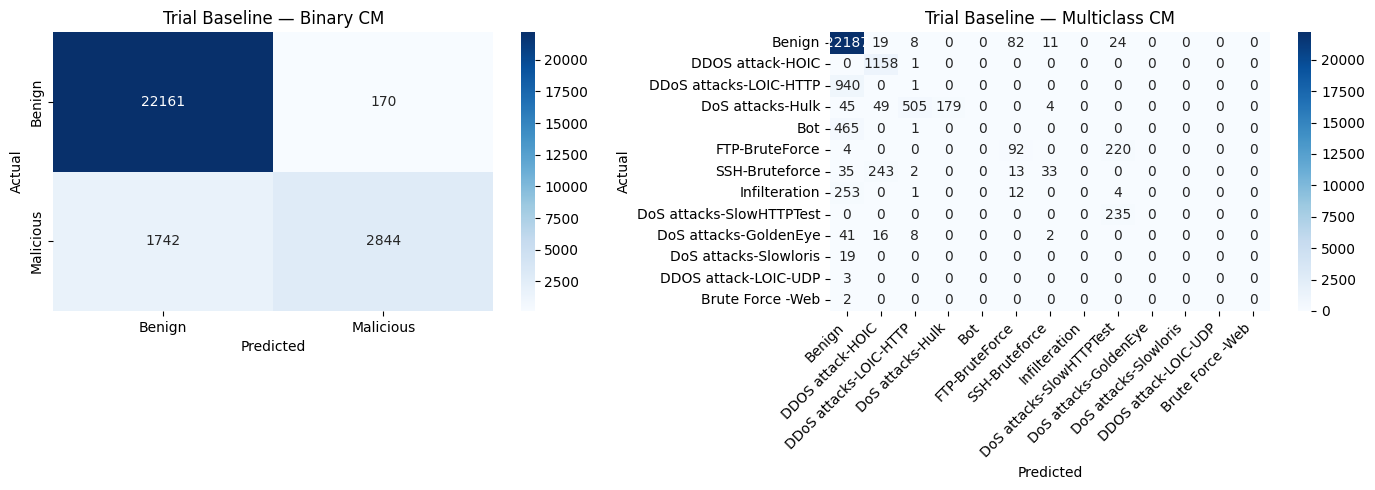

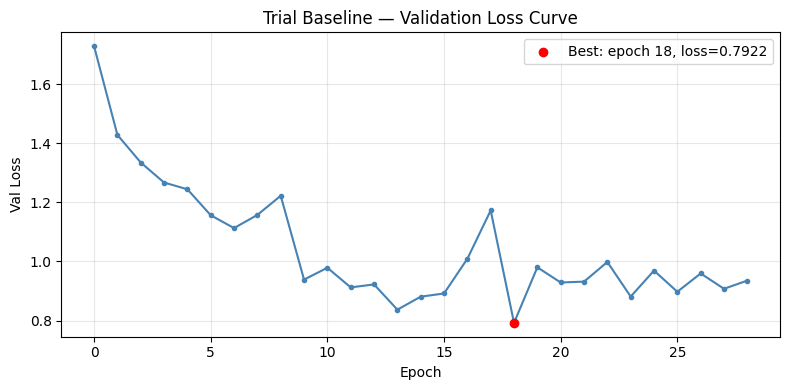

  Trial Baseline: MCC_bin=0.7303, MCC_mul=0.5801, mean=0.6552, F1_bin=0.7484, F1_mul=0.2612


0.5047924736651442

In [40]:
# ── Step 5c: Retrain CNN-LSTM Baseline ─────────────────────────────────────
print(f"🏋️  Training CNN-LSTM baseline (optimized HP, {PERCENTAGE_TO_USE*100:.1f}% data, top features) ...")

new_batch_cnn_lstm = min(
    int(best_cnn_lstm['batch_size'] * (PERCENTAGE_TO_USE / 0.001)),  # Linear scaling rule (He et al.)
    4096  # cap massimo
)

cnn_lstm_multitask_objective(   
    X_base_train, X_base_val,
    y_base_tr_bin, y_base_tr_mul,
    y_base_val_bin, y_base_val_mul,
    best_cnn_lstm['nb_filters'], best_cnn_lstm['kernel_size'],
    best_cnn_lstm['lstm_units_1'], best_cnn_lstm['lstm_units_2'],
    best_cnn_lstm['dropout'], best_cnn_lstm['lr']/2, #scaling 
    batch_size=new_batch_cnn_lstm,
    verbose=1, 
    label_model='Baseline',
    feature_names=FEATURE_NAMES
)

Here we can clearly see that for CNN-LST performance are drastically reduced from what is achieved in orginal paper, this is for a combination of different factors:
1. we are only using 10% of dataset instead of 100% as original paper.
2. we are only using 9 of total 80 fetures

questi retsraint sono dati non solo dalla complessità eccesiva di dover elaborare 16 milioni di righe (per il quale mi manca completamente la potenza computazionale). Ma anche per motivi di tempo. Far girare questi modelli diverse volte richiede un enorme quantitativo di tempo che renderebbe il lavoro computazionalmente insostenibile date le mie risorse. 

avere un degradazione delle performance è perfettamente normale, comunque riusciamo ad ottere un f1-score (pesato per ogni classe) abbastanza alto che per una baseline ci soddisfa

🏋️  Training TabNet baseline (optimized HP, 10.0% data, top features) ...
epoch 0  | loss: 0.58916 | val_0_accuracy: 0.90546 |  0:00:36s
epoch 1  | loss: 0.15849 | val_0_accuracy: 0.9177  |  0:01:11s
epoch 2  | loss: 0.13412 | val_0_accuracy: 0.96032 |  0:01:48s
epoch 3  | loss: 0.12692 | val_0_accuracy: 0.94939 |  0:02:24s
epoch 4  | loss: 0.12272 | val_0_accuracy: 0.96133 |  0:03:00s
epoch 5  | loss: 0.11925 | val_0_accuracy: 0.96225 |  0:03:35s
epoch 6  | loss: 0.11633 | val_0_accuracy: 0.96195 |  0:04:11s
epoch 7  | loss: 0.11511 | val_0_accuracy: 0.9629  |  0:04:46s
epoch 8  | loss: 0.11412 | val_0_accuracy: 0.96218 |  0:05:21s
epoch 9  | loss: 0.11215 | val_0_accuracy: 0.96427 |  0:05:56s
epoch 10 | loss: 0.11177 | val_0_accuracy: 0.96364 |  0:06:33s
epoch 11 | loss: 0.11052 | val_0_accuracy: 0.96761 |  0:07:08s
epoch 12 | loss: 0.10937 | val_0_accuracy: 0.95663 |  0:07:43s
epoch 13 | loss: 0.109   | val_0_accuracy: 0.96686 |  0:08:18s
epoch 14 | loss: 0.10813 | val_0_accuracy: 0

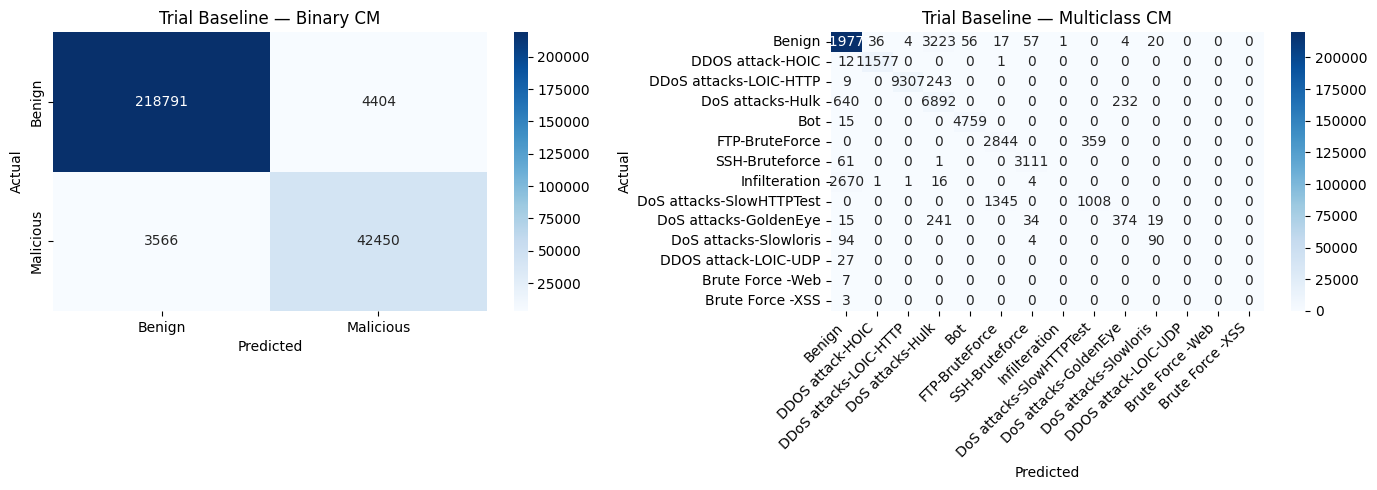


  Trial Baseline - Binary Task
  Accuracy : 0.9704  |  F1: 0.9142  |  MCC: 0.8963  |  AUC: 0.9788
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98    223195
   Malicious       0.91      0.92      0.91     46016

    accuracy                           0.97    269211
   macro avg       0.94      0.95      0.95    269211
weighted avg       0.97      0.97      0.97    269211


  Trial Baseline - Multiclass Task
  Accuracy : 0.9648  |  F1: 0.5816  |  MCC: 0.8859  |  AUC: nan
                          precision    recall  f1-score   support

                  Benign       0.98      0.98      0.98    223195
        DDOS attack-HOIC       1.00      1.00      1.00     11590
  DDoS attacks-LOIC-HTTP       1.00      0.97      0.99      9559
        DoS attacks-Hulk       0.65      0.89      0.75      7764
                     Bot       0.99      1.00      0.99      4774
          FTP-BruteForce       0.68      0.89      0.77      3203
          S

0.8911030334318913

In [ ]:
# ── Step 5b: Retrain TabNet Baseline ──────────────────────────────────
print(f"🏋️  Training TabNet baseline (optimized HP, {PERCENTAGE_TO_USE*100:.1f}% data, top features) ...")

new_batch_tabnet = min(
    int(best_tabnet['batch_size'] * (PERCENTAGE_TO_USE / 0.001)),  # Linear scaling rule (He et al.)
    4096  # cap massimo
)

tabnet_multitask_objective(
    X_base_train_2d, X_base_val_2d,
    y_base_tr_bin_2d, y_base_tr_mul_2d,
    y_base_val_bin_2d, y_base_val_mul_2d,
    best_tabnet['N_a'], best_tabnet['N_steps'], best_tabnet['gamma'],
    (best_tabnet['lambda_sparse'] * ((0.001 / PERCENTAGE_TO_USE) ** 0.5)),
    best_tabnet['lr'], 
    new_batch_tabnet,
    best_tabnet['mask_type'],
    verbose=1, trial=None, label_model='Baseline',
    feature_names=FEATURE_NAMES
)

invece per quest'altro modello (che è molto più all'avanguardia rispetto una normale LSTM) si ottengono ancora ottime performance, ed, ironicamente, si hanno tempi di train estremamente più bassi rispetto al modello precedente. 